In [ ]:
%pip install scikit-learn
%pip install pandas
%pip install matplotlib
%pip install numpy

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df1 = pd.read_csv('C:/Users/User/Downloads/Module_3_Material/protein_data/pdb_data_no_dups.csv')
df2 = pd.read_csv('C:/Users/User/Downloads/Module_3_Material/protein_data/pdb_data_seq.csv')

df = pd.merge(df1, df2[['structureId', 'chainId', 'sequence']], on='structureId', how='inner')
df.head()

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear,chainId,sequence
0,100D,DNA-RNA HYBRID,X-RAY DIFFRACTION,DNA/RNA Hybrid,20,1.90,6360.30,"VAPOR DIFFUSION, HANGING DROP",NaN,1.78,30.89,"pH 7.00, VAPOR DIFFUSION, HANGING DROP",7.0,1994.0,A,CCGGCGCCGG
1,100D,DNA-RNA HYBRID,X-RAY DIFFRACTION,DNA/RNA Hybrid,20,1.90,6360.30,"VAPOR DIFFUSION, HANGING DROP",NaN,1.78,30.89,"pH 7.00, VAPOR DIFFUSION, HANGING DROP",7.0,1994.0,B,CCGGCGCCGG
2,101D,DNA,X-RAY DIFFRACTION,DNA,24,2.25,7939.35,NaN,NaN,2.00,38.45,NaN,NaN,1995.0,A,CGCGAATTCGCG
3,101D,DNA,X-RAY DIFFRACTION,DNA,24,2.25,7939.35,NaN,NaN,2.00,38.45,NaN,NaN,1995.0,B,CGCGAATTCGCG
4,101M,OXYGEN TRANSPORT,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.0,1999.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...


Total number of protein classes

In [3]:
df = df[df['macromoleculeType'] == "Protein"]
print(df.shape)
len(df[df['macromoleculeType'] == "Protein"]['classification'].value_counts())

(346325, 16)


4468

Missing values per column in percentage

In [4]:

for i, v in df.isnull().sum().items():
    print(i, " : ", round((v/471149)*100, 1))

structureId  :  0.0
classification  :  0.0
experimentalTechnique  :  0.0
macromoleculeType  :  0.0
residueCount  :  0.0
resolution  :  3.4
structureMolecularWeight  :  0.0
crystallizationMethod  :  22.4
crystallizationTempK  :  21.7
densityMatthews  :  8.2
densityPercentSol  :  8.2
pdbxDetails  :  11.0
phValue  :  18.5
publicationYear  :  10.8
chainId  :  0.0
sequence  :  0.0


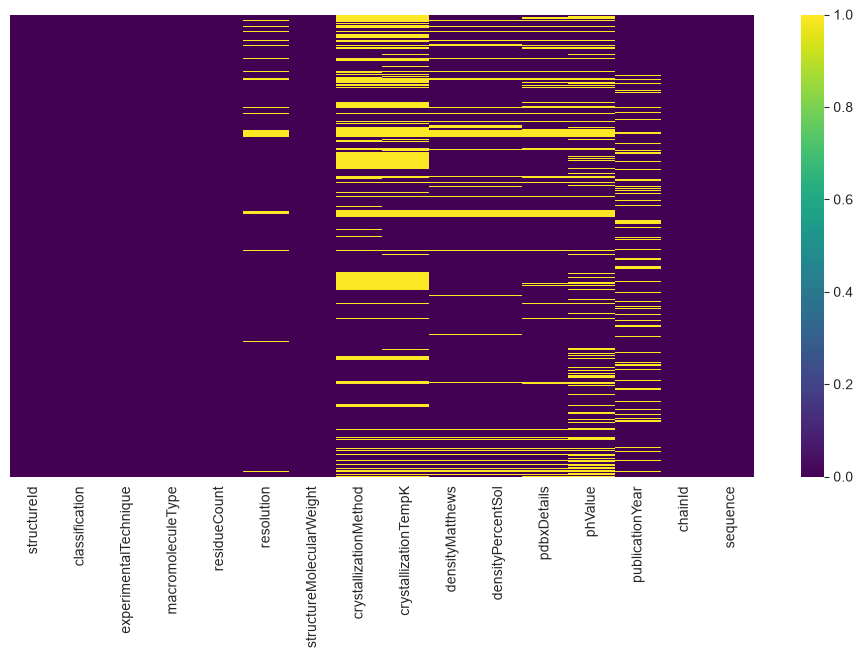

In [5]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), yticklabels=False,cbar=True, cmap='viridis')
plt.show()

In [6]:
df['classification'] = df['classification'].astype('str')
df = df[df['macromoleculeType'] == "Protein"]
df.reset_index(inplace=True, drop=True)

df['classification'] = df['classification'].str.lower()
df['classification'] = df['classification'].str.replace('(', '/', regex=False)
df['classification'] = df['classification'].str.replace(', ', '/', regex=False)
df['classification'] = df['classification'].str.replace(',', '/', regex=False)
df['classification'] = df['classification'].str.replace('/ ', '/', regex=False)
df['classification'] = df['classification'].str.replace(')', '', regex=False)
# pattern = '|'.join([', ', ',', '('])
# df['classification'] = df['classification'].str.replace(pattern, '/')

# Maintaing class ordering. There are the same classes with different order
#ex. viral protein/immune system and immune system/viral protein
df['classification'] = df['classification'].apply(lambda x: "/".join(sorted(str(x).split('/'))))

df.head(3)

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear,chainId,sequence
0,101M,oxygen transport,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.0,1999.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...
1,102L,hydrolase/o-glycosyl,X-RAY DIFFRACTION,Protein,165,1.74,18926.61,NaN,NaN,2.75,55.28,NaN,NaN,1993.0,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAAKSE...
2,102M,oxygen transport,X-RAY DIFFRACTION,Protein,154,1.84,18010.64,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.0,1999.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...


Deleting outliar 23 values for <b>Molecular weight</b> which was for Virus classification. It was a very small number so was deleted.

<b> Note: </b> Molecular weight is calculated using sequence using the weight of each amino acid. Thus, if sequence is long, then it can have large weight


<Axes: xlabel='structureMolecularWeight', ylabel='densityMatthews'>

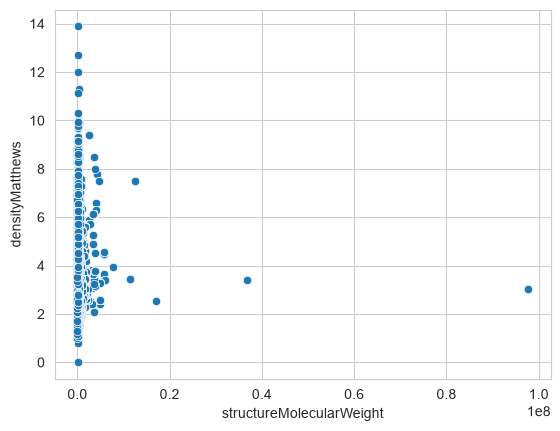

In [7]:
sns.scatterplot(x="structureMolecularWeight", y="densityMatthews", data=df)

# Later check: You can compare weight with sequence length

<Axes: xlabel='structureMolecularWeight', ylabel='densityMatthews'>

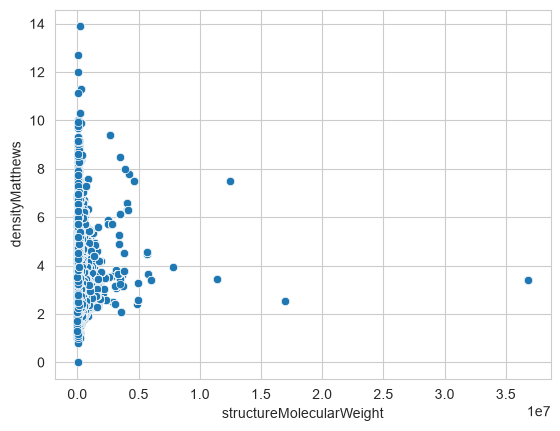

In [8]:
#density_weight = df[['classification','densityMatthews','structureMolecularWeight']].dropna().copy()
weight_max = df['structureMolecularWeight'] == df['structureMolecularWeight'].max()
df = df[~weight_max].copy()
sns.scatterplot(x="structureMolecularWeight", y="densityMatthews", data=df)

Dealing with outliar of phValue. 

<Axes: xlabel='phValue'>

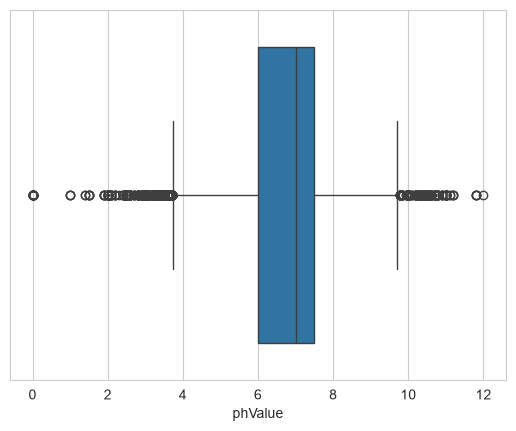

In [9]:
df['phValue'] = df['phValue'].replace(100, np.nan)
sns.boxplot(x=df['phValue'].dropna())

In [10]:
df.phValue.isnull().sum()

np.int64(87203)

In [11]:
df.columns

Index(['structureId', 'classification', 'experimentalTechnique',
       'macromoleculeType', 'residueCount', 'resolution',
       'structureMolecularWeight', 'crystallizationMethod',
       'crystallizationTempK', 'densityMatthews', 'densityPercentSol',
       'pdbxDetails', 'phValue', 'publicationYear', 'chainId', 'sequence'],
      dtype='str')

In [12]:
df.drop(['crystallizationMethod','crystallizationTempK', 'publicationYear', 'pdbxDetails'], axis=1, inplace=True) 
df.dropna(subset=['densityMatthews','densityPercentSol','resolution', 'sequence'], inplace=True)

Filter dataset's records for classification types which are > 100

In [13]:
counts = df['classification'].value_counts()

types = np.asarray(counts[(counts > 100)].index)

data = df[df.classification.isin(types)].copy()
data.head(3)

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,phValue,chainId,sequence
0,101M,oxygen transport,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,3.09,60.20,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...
1,102L,hydrolase/o-glycosyl,X-RAY DIFFRACTION,Protein,165,1.74,18926.61,2.75,55.28,NaN,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAAKSE...
2,102M,oxygen transport,X-RAY DIFFRACTION,Protein,154,1.84,18010.64,3.09,60.20,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...


In [14]:
data.phValue.isnull().sum()

np.int64(45034)

Handling Outliar of PhValue

In [15]:
class_dict = dict()
count = 0

classes = data['classification'].value_counts().items()

for cat, num in classes:
    
    # Remove all other classes that have number of values are less than 100
    if num < 100:
        temp = data['classification'] == cat
        data = data[~temp].copy()
        continue
        
    # Remove all a class if all phValues are null
    if data[(data['classification'] == cat) & (data['phValue'].notnull())].phValue.count() == 0:
        temp = data['classification'] == cat
        data = data[~temp].copy()
        continue
    
    ph_mean = round(data[data['classification'] == cat]['phValue'].dropna().mean(),2)
    data.loc[(data['classification'] == cat) & (data['phValue'].isna()),'phValue'] = ph_mean
    
    
    
    if num >= 100:
        class_dict[cat] = count
        count += 1

class_dict

{'hydrolase': 0,
 'transferase': 1,
 'oxidoreductase': 2,
 'immune system': 3,
 'hydrolase/hydrolase inhibitor': 4,
 'lyase': 5,
 'transcription': 6,
 'transport protein': 7,
 'viral protein': 8,
 'isomerase': 9,
 'signaling protein': 10,
 'ligase': 11,
 'structural genomics/unknown function': 12,
 'transferase/transferase inhibitor': 13,
 'protein binding': 14,
 'membrane protein': 15,
 'sugar binding protein': 16,
 'chaperone': 17,
 'structural protein': 18,
 'dna binding protein': 19,
 'cell adhesion': 20,
 'electron transport': 21,
 'metal binding protein': 22,
 'unknown function': 23,
 'cell cycle': 24,
 'toxin': 25,
 'protein transport': 26,
 'photosynthesis': 27,
 'oxidoreductase/oxidoreductase inhibitor': 28,
 'rna binding protein': 29,
 'immune system/viral protein': 30,
 'de novo protein': 31,
 'gene regulation': 32,
 'hormone': 33,
 'virus': 34,
 'apoptosis': 35,
 'metal transport': 36,
 'fluorescent protein': 37,
 'transcription regulator': 38,
 'biosynthetic protein': 39,


In [16]:
data['class'] = data['classification'].map(class_dict)
data.head()

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,phValue,chainId,sequence,class
0,101M,oxygen transport,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,3.09,60.2,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,40
2,102M,oxygen transport,X-RAY DIFFRACTION,Protein,154,1.84,18010.64,3.09,60.2,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,40
4,103M,oxygen transport,X-RAY DIFFRACTION,Protein,154,2.07,18093.78,3.09,60.3,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,40
7,104M,oxygen transport,X-RAY DIFFRACTION,Protein,153,1.71,18030.63,1.87,34.3,7.0,A,VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRF...,40
8,105M,oxygen transport,X-RAY DIFFRACTION,Protein,153,2.02,18030.63,1.83,33.0,9.0,A,VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRF...,40


In [17]:
data.isnull().sum()

structureId                 0
classification              0
experimentalTechnique       0
macromoleculeType           0
residueCount                0
resolution                  0
structureMolecularWeight    0
densityMatthews             0
densityPercentSol           0
phValue                     0
chainId                     0
sequence                    0
class                       0
dtype: int64

In [18]:
data.info()

<class 'pandas.DataFrame'>
Index: 281332 entries, 0 to 346324
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   structureId               281332 non-null  str    
 1   classification            281332 non-null  str    
 2   experimentalTechnique     281332 non-null  str    
 3   macromoleculeType         281332 non-null  str    
 4   residueCount              281332 non-null  int64  
 5   resolution                281332 non-null  float64
 6   structureMolecularWeight  281332 non-null  float64
 7   densityMatthews           281332 non-null  float64
 8   densityPercentSol         281332 non-null  float64
 9   phValue                   281332 non-null  float64
 10  chainId                   281332 non-null  str    
 11  sequence                  281332 non-null  str    
 12  class                     281332 non-null  int64  
dtypes: float64(5), int64(2), str(6)
memory usage: 30.0 MB


In [19]:
data.describe()

,residueCount,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,phValue,class
count,281332.000000,281332.000000,2.813320e+05,281332.000000,281332.000000,281332.000000,281332.000000
mean,1690.615405,2.302731,1.949728e+05,2.756481,52.780551,6.797744,14.497732
std,2852.967585,0.649239,4.261830e+05,0.732825,10.088634,1.137000,23.883042
min,4.000000,0.480000,4.685500e+02,0.000000,0.000000,0.000000,0.000000
25%,424.000000,1.900000,4.789657e+04,2.280000,45.820000,6.300000,1.000000
50%,844.000000,2.200000,9.568248e+04,2.560000,51.920000,6.830000,5.000000
75%,1760.000000,2.680000,1.978216e+05,3.020000,59.290000,7.500000,17.000000
max,57792.000000,9.100000,3.683173e+07,13.890000,90.330000,12.000000,145.000000


## Exploratory Data Analysis

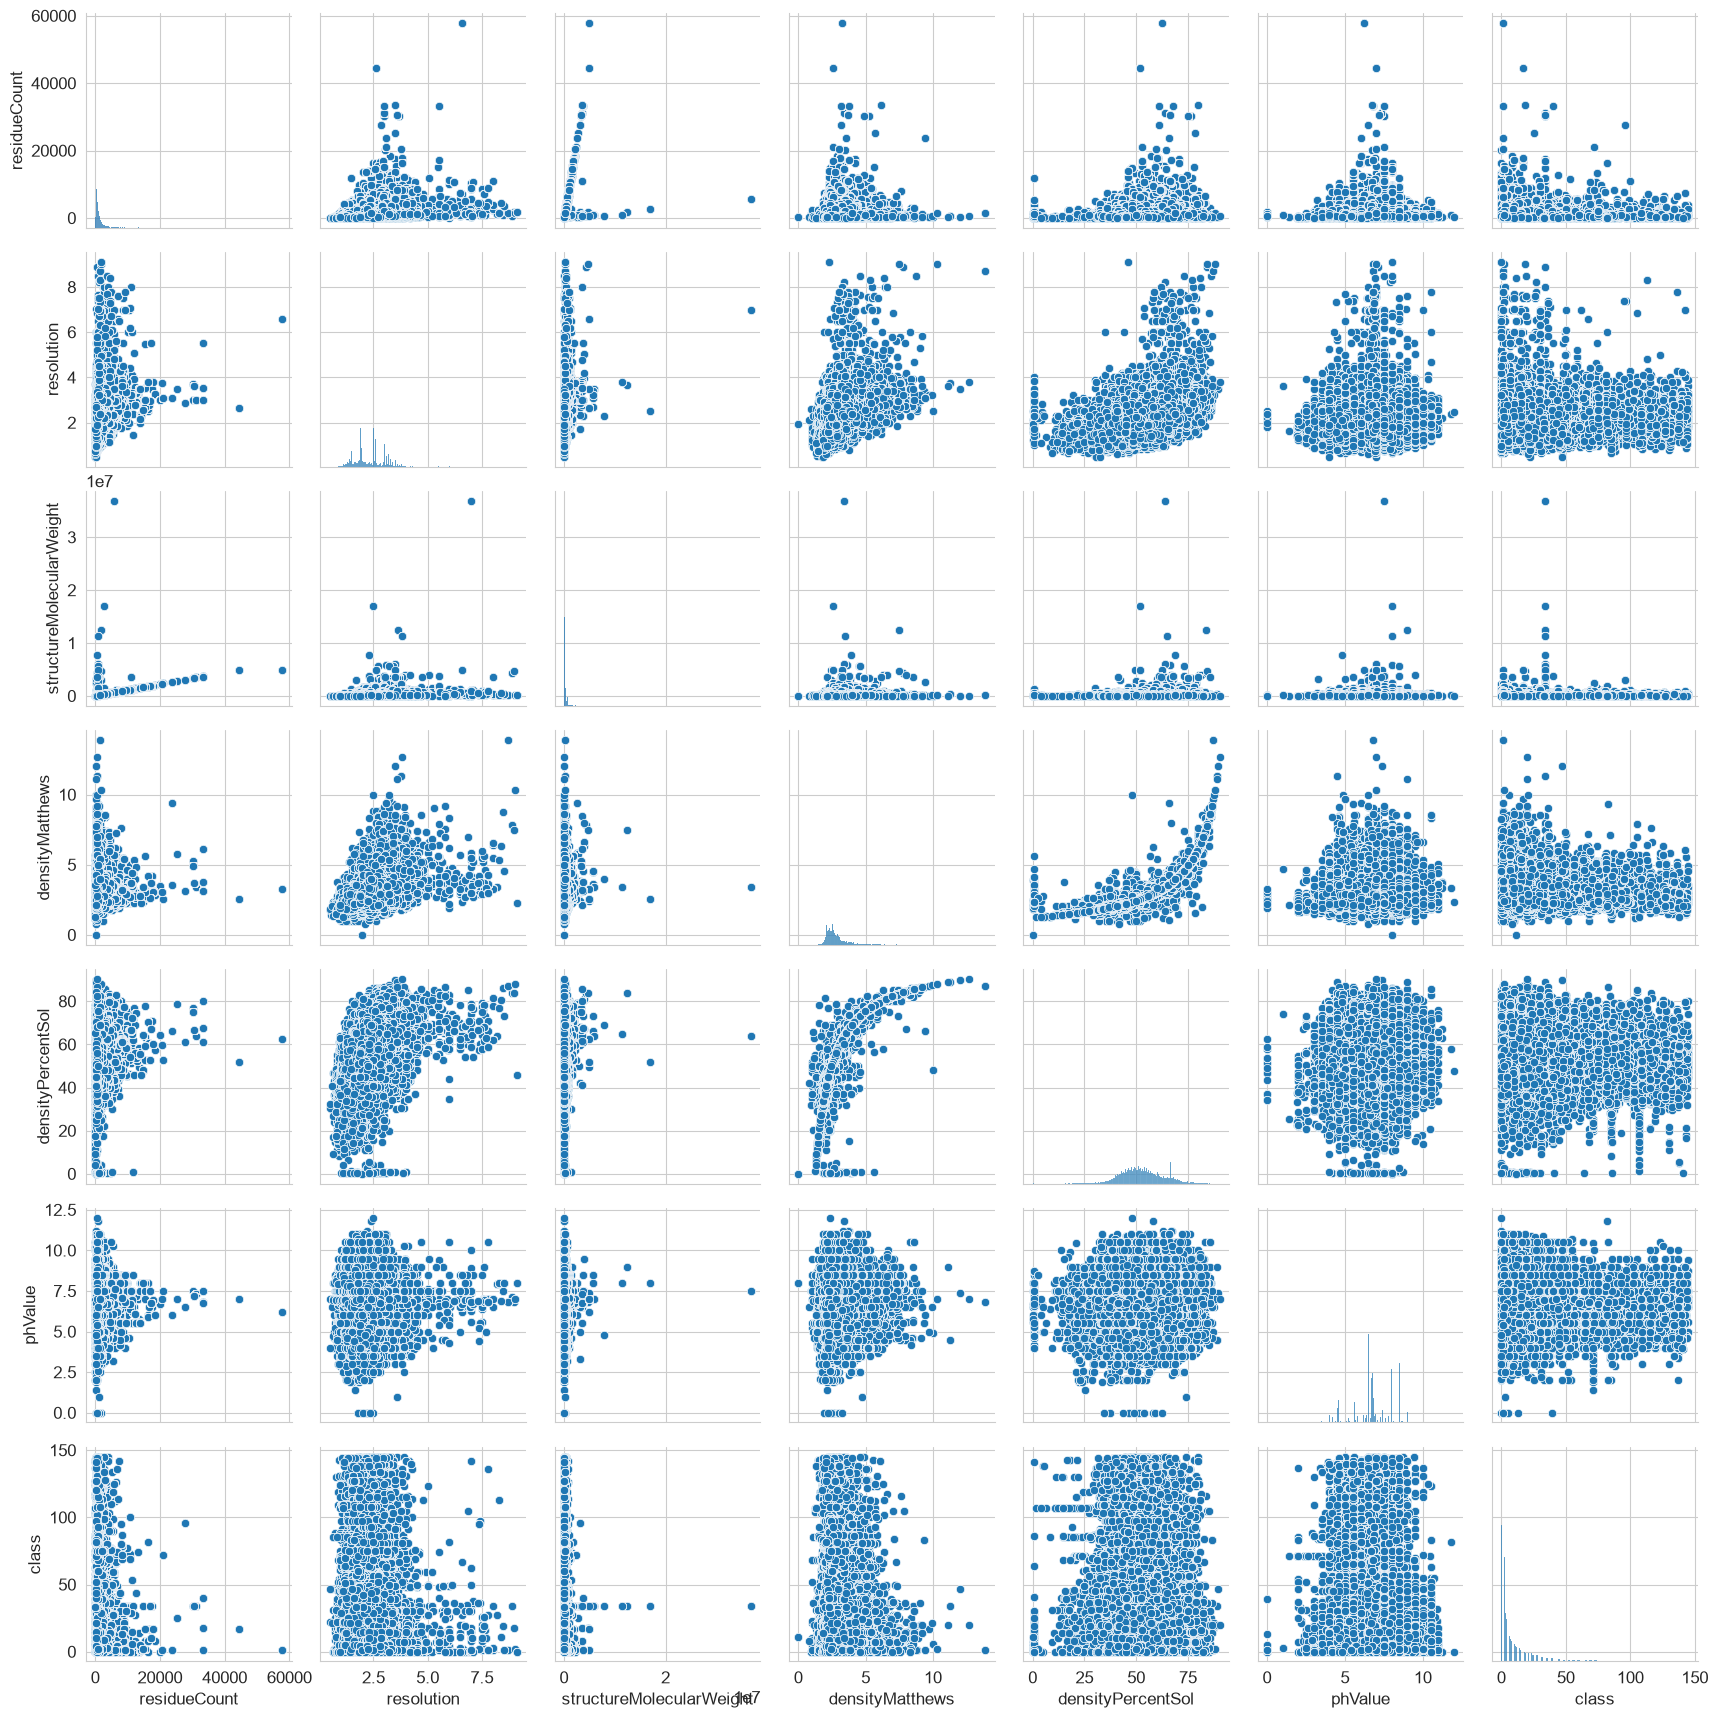

In [20]:
plt.rcParams['font.size'] = 12
sns.pairplot(data.select_dtypes(include=[np.number]))

In [21]:
def set_phlevel(x):
    if x > 7:
        return 'Basic'
    elif x < 7:
        return 'Acidic'
    else:
        return 'Neutral'

data['ph_level'] = data['phValue'].apply(set_phlevel)
ph_level = data.groupby('ph_level')['ph_level'].count()

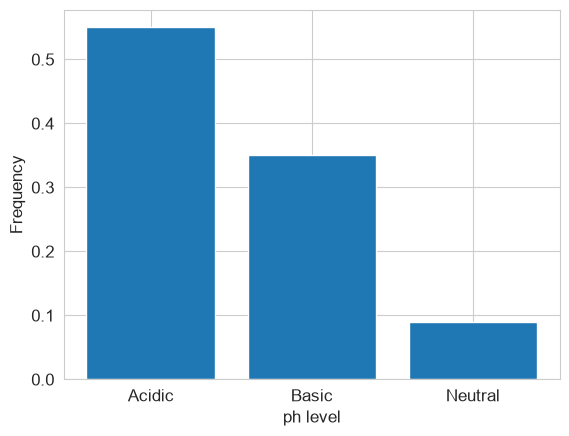

In [22]:
# labels = ph_level.index.tolist()
# sizes = np.round((ph_level.values) * 100 / sum(ph_level.values), 2).tolist()
# fig1, ax1 = plt.subplots()
# ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
# ax1.axis('equal')  
# plt.tight_layout()
# plt.show()

labels = ph_level.index.tolist()
sizes = np.round((ph_level.values) / sum(ph_level.values), 2).tolist()
plt.bar(x=labels, height=sizes)
plt.xlabel('ph level')
plt.ylabel('Frequency');

In [23]:
data['seq_len'] = data['sequence'].apply(lambda x: len(x))
data.head()

,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,phValue,chainId,sequence,class,ph_level,seq_len
0,101M,oxygen transport,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,3.09,60.2,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,40,Basic,154
2,102M,oxygen transport,X-RAY DIFFRACTION,Protein,154,1.84,18010.64,3.09,60.2,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,40,Basic,154
4,103M,oxygen transport,X-RAY DIFFRACTION,Protein,154,2.07,18093.78,3.09,60.3,9.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,40,Basic,154
7,104M,oxygen transport,X-RAY DIFFRACTION,Protein,153,1.71,18030.63,1.87,34.3,7.0,A,VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRF...,40,Neutral,153
8,105M,oxygen transport,X-RAY DIFFRACTION,Protein,153,2.02,18030.63,1.83,33.0,9.0,A,VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRF...,40,Basic,153


<Axes: xlabel='densityMatthews', ylabel='densityPercentSol'>

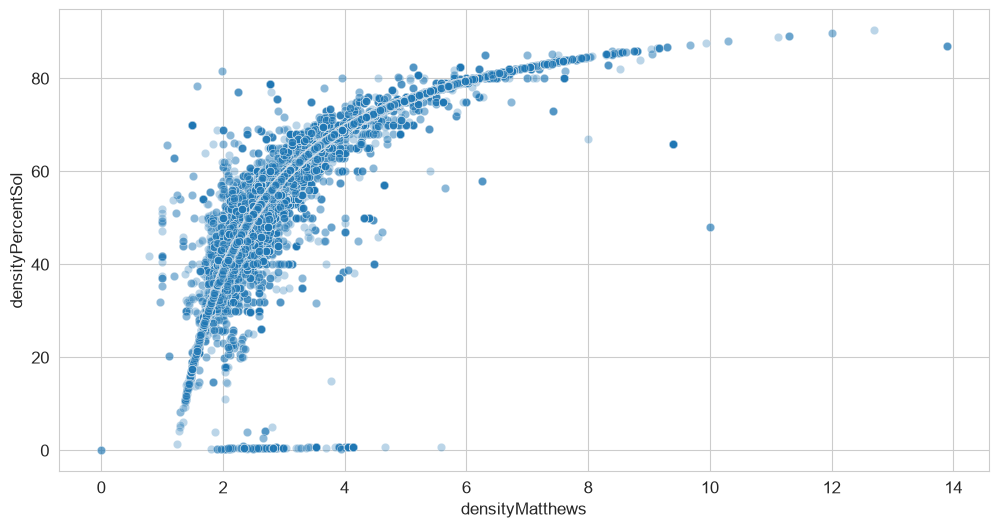

In [24]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='densityMatthews', y='densityPercentSol', data=data, alpha=0.3)

## Building a signle train-test split model

In [25]:
X = data[['residueCount','resolution','structureMolecularWeight','densityMatthews','densityPercentSol','phValue']]
y = data['class']

scaler = StandardScaler().fit(X)
X_norm =  scaler.transform(X)
X_scaled = pd.DataFrame(X_norm, columns=X.columns)
X_scaled.shape

(281332, 6)

In [26]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
scaler = StandardScaler().fit(X_train)
X_train_norm =  scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_norm, columns=X.columns)
X_train_scaled.head()


,residueCount,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,phValue
0,-0.220375,-0.235087,-0.184187,0.332947,0.647095,0.002975
1,-0.497711,-1.082698,-0.382236,-0.718135,-0.787269,-1.580527
2,-0.163359,1.074858,-0.135622,-0.431476,-0.313443,1.762421
3,-0.361859,0.288891,-0.290050,-1.032094,-1.416725,1.058642
4,-0.046512,-0.589543,-0.046211,-0.445127,-0.341199,0.178919


In [28]:
X_test_norm = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_norm, columns=X.columns)
X_test_scaled.head()

,residueCount,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,phValue
0,-0.404796,-0.851532,-0.314985,-0.663533,-0.686160,0.882698
1,-0.463572,-0.928587,-0.358400,-0.636232,-0.634614,-0.260942
2,-0.467443,-0.712831,-0.356022,-0.008313,0.241667,0.178919
3,-0.462164,-0.620365,-0.358528,-0.335923,-0.180613,1.498504
4,0.677798,-0.389198,0.583852,1.848143,1.717665,-0.005823


### Random Forest

In [29]:
#Random Forest with singal train-test split
m = RandomForestClassifier(n_estimators=40, min_samples_leaf=3, n_jobs=-1)
m.fit(X_train, y_train)

predictions = m.predict(X_test)
print(classification_report(y_test, predictions))
print("Accuracy :",accuracy_score(y_test, predictions),'\n')

              precision    recall  f1-score   support

           0       0.77      0.91      0.84      8651
           1       0.80      0.91      0.85      6902
           2       0.90      0.91      0.91      6623
           3       0.88      0.95      0.91      2980
           4       0.94      0.92      0.93      2700
           5       0.93      0.88      0.90      2314
           6       0.85      0.86      0.86      1641
           7       0.88      0.83      0.86      1455
           8       0.94      0.90      0.92      1283
           9       0.94      0.78      0.85      1280
          10       0.87      0.80      0.83      1073
          11       0.90      0.77      0.83       902
          12       0.88      0.75      0.81       948
          13       0.87      0.76      0.81       938
          14       0.89      0.84      0.86       815
          15       0.94      0.84      0.89       712
          16       0.92      0.81      0.86       674
          17       0.94    

In [30]:
# Random Forest with cross validation and grid search
param_grid = [{'n_estimators':[30, 40], 
               'max_features':[4,6]}]

m = RandomForestClassifier(n_estimators=40, min_samples_leaf=3, n_jobs=-1)
kfold = KFold(n_splits=10, random_state=42, shuffle=True)
grid_search = GridSearchCV(m, param_grid, cv=kfold)
grid_search.fit(X_train, y_train)

print("Train Accuracy :",grid_search.best_score_)
print(grid_search.best_params_)
print(grid_search.best_estimator_)

predictions = grid_search.predict(X_test)
print("Test Accuracy :",accuracy_score(y_test, predictions),'\n')

Train Accuracy : 0.8623330871190676
{'max_features': 4, 'n_estimators': 40}
RandomForestClassifier(max_features=4, min_samples_leaf=3, n_estimators=40,
                       n_jobs=-1)
Test Accuracy : 0.8728562034585103 



### Decision Tree

In [31]:
# Decision tree with singal train-test split
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)
print(classification_report(y_test, predictions))
print("Accuracy :",accuracy_score(y_test, predictions),'\n')

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      8651
           1       0.90      0.89      0.89      6902
           2       0.93      0.92      0.92      6623
           3       0.94      0.96      0.95      2980
           4       0.94      0.95      0.94      2700
           5       0.92      0.91      0.91      2314
           6       0.87      0.89      0.88      1641
           7       0.88      0.86      0.87      1455
           8       0.91      0.93      0.92      1283
           9       0.88      0.86      0.87      1280
          10       0.82      0.86      0.84      1073
          11       0.85      0.84      0.85       902
          12       0.81      0.83      0.82       948
          13       0.81      0.80      0.80       938
          14       0.83      0.89      0.86       815
          15       0.89      0.89      0.89       712
          16       0.84      0.89      0.86       674
          17       0.90    

In [32]:
#Decision Tree with cross validation and grid search
param_grid = [{'max_depth':[5,10],
              'min_samples_leaf':[1, 5, 10]}]

dtree = DecisionTreeClassifier()
kfold = KFold(n_splits=10, random_state=42, shuffle=True)
grid_search = GridSearchCV(dtree, param_grid, cv=kfold)
grid_search.fit(X_train, y_train)
print("Train Accuracy :",grid_search.best_score_)
print(grid_search.best_params_)
print(grid_search.best_estimator_)

predictions = grid_search.predict(X_test)
print("Test Accuracy :",accuracy_score(y_test, predictions),'\n')

Train Accuracy : 0.3079288114363354
{'max_depth': 10, 'min_samples_leaf': 1}
DecisionTreeClassifier(max_depth=10)
Test Accuracy : 0.30428137274068284 



### Gradient Boosting

### Gaussian Naive Bayes

In [33]:

m = GaussianNB()
m.fit(X_train, y_train)
predictions = m.predict(X_test)
print(classification_report(y_test, predictions))
print("Accuracy :",accuracy_score(y_test, predictions),'\n')

              precision    recall  f1-score   support

           0       0.17      0.02      0.04      8651
           1       0.19      0.00      0.01      6902
           2       0.22      0.27      0.24      6623
           3       0.07      0.59      0.13      2980
           4       0.33      0.45      0.38      2700
           5       0.00      0.00      0.00      2314
           6       0.00      0.00      0.00      1641
           7       0.00      0.00      0.00      1455
           8       0.00      0.00      0.00      1283
           9       0.00      0.00      0.00      1280
          10       0.00      0.00      0.00      1073
          11       0.00      0.00      0.00       902
          12       0.00      0.00      0.00       948
          13       0.00      0.00      0.00       938
          14       0.00      0.00      0.00       815
          15       0.00      0.00      0.00       712
          16       0.00      0.00      0.00       674
          17       0.08    

c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [34]:
nb = GaussianNB()
kfold = KFold(n_splits=10, random_state=42, shuffle=True)
scores = cross_val_score(nb, X_train, y_train, cv=kfold)

print(scores)
print(scores.mean())



[0.09716977 0.09432621 0.09290443 0.09650331 0.0944595  0.09606327
 0.09299742 0.09166445 0.09579668 0.09535235]
0.09472373872202822


### Multinomial Naive Bayes

In [35]:
m = MultinomialNB()
m.fit(X_train, y_train)
predictions = m.predict(X_test)
print(classification_report(y_test, predictions))
print("Accuracy :",accuracy_score(y_test, predictions),'\n')

              precision    recall  f1-score   support

           0       0.12      0.04      0.06      8651
           1       0.15      0.07      0.09      6902
           2       0.21      0.11      0.15      6623
           3       0.06      0.09      0.07      2980
           4       0.01      0.01      0.01      2700
           5       0.00      0.00      0.00      2314
           6       0.03      0.04      0.04      1641
           7       0.00      0.00      0.00      1455
           8       0.07      0.03      0.04      1283
           9       0.00      0.00      0.00      1280
          10       0.00      0.00      0.00      1073
          11       0.00      0.00      0.00       902
          12       0.02      0.09      0.03       948
          13       0.00      0.00      0.00       938
          14       0.00      0.00      0.00       815
          15       0.14      0.00      0.00       712
          16       0.02      0.05      0.02       674
          17       0.02    

c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [36]:
m = MultinomialNB()
kfold = KFold(n_splits=10, random_state=42, shuffle=True)
scores = cross_val_score(m, X_train, y_train, cv=kfold)
print(scores)
print(scores.mean())

[0.04643    0.04478607 0.04558582 0.04300884 0.04696317 0.04349951
 0.04381054 0.04709855 0.04736515 0.04549898]
0.04540466198394842


###  Support Vector Machine

In [37]:
svm = LinearSVC()

svm.fit(X_train_scaled, y_train)

predictions = svm.predict(X_test_scaled)
print(classification_report(y_test, predictions))
print("Accuracy :",accuracy_score(y_test, predictions),'\n')

              precision    recall  f1-score   support

           0       0.17      0.84      0.28      8651
           1       0.12      0.14      0.13      6902
           2       0.15      0.09      0.11      6623
           3       0.09      0.01      0.01      2980
           4       0.00      0.00      0.00      2700
           5       0.00      0.00      0.00      2314
           6       0.00      0.00      0.00      1641
           7       0.09      0.01      0.02      1455
           8       0.00      0.00      0.00      1283
           9       0.00      0.00      0.00      1280
          10       0.00      0.00      0.00      1073
          11       0.00      0.00      0.00       902
          12       0.00      0.00      0.00       948
          13       0.00      0.00      0.00       938
          14       0.00      0.00      0.00       815
          15       0.00      0.00      0.00       712
          16       0.00      0.00      0.00       674
          17       0.00    

c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

### K Nearest Neighbors 

In [38]:
#KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
predictions = knn.predict(X_test_scaled)
print(classification_report(y_test, predictions))
print("Accuracy :",accuracy_score(y_test, predictions),'\n')

              precision    recall  f1-score   support

           0       0.62      0.72      0.66      8651
           1       0.63      0.69      0.66      6902
           2       0.76      0.73      0.75      6623
           3       0.72      0.84      0.77      2980
           4       0.77      0.78      0.78      2700
           5       0.72      0.68      0.70      2314
           6       0.65      0.68      0.66      1641
           7       0.66      0.61      0.63      1455
           8       0.74      0.77      0.75      1283
           9       0.69      0.61      0.65      1280
          10       0.60      0.58      0.59      1073
          11       0.67      0.56      0.61       902
          12       0.59      0.55      0.57       948
          13       0.58      0.43      0.50       938
          14       0.68      0.63      0.65       815
          15       0.72      0.65      0.68       712
          16       0.67      0.61      0.64       674
          17       0.80    

In [39]:
# K-nearest naighbour with grid search and cross validation
param_grid = [{'n_neighbors':[3, 5, 10, 15], 
               'weights':['uniform','distance']}]
#'metric':['euclidean','manhattan']

knn = KNeighborsClassifier(n_neighbors=3)
kfold = KFold(n_splits=10, random_state=42, shuffle=True)

grid_search = GridSearchCV(knn, param_grid, cv=kfold)
grid_search.fit(X_train_scaled, y_train)

print("Train Accuracy :",grid_search.best_score_)
print(grid_search.best_params_)
print(grid_search.best_estimator_)

predictions = grid_search.predict(X_test_scaled)
print("Test Accuracy :",accuracy_score(y_test, predictions),'\n')

Train Accuracy : 0.8355097175628735
{'n_neighbors': 15, 'weights': 'distance'}
KNeighborsClassifier(n_neighbors=15, weights='distance')
Test Accuracy : 0.852204667033963 



### Logistic Regression with OneVsRest Classifier

In [40]:
# Logistic with single train test split
logreg = LogisticRegression(random_state=42, solver='lbfgs')
mulreg = OneVsRestClassifier(logreg)
mulreg.fit(X_train, y_train)
predictions = mulreg.predict(X_test)
print(classification_report(y_test, predictions))
print("Accuracy :",accuracy_score(y_test, predictions),'\n')

c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

              precision    recall  f1-score   support

           0       0.16      0.99      0.27      8651
           1       0.00      0.00      0.00      6902
           2       0.17      0.02      0.04      6623
           3       0.00      0.00      0.00      2980
           4       0.00      0.00      0.00      2700
           5       0.00      0.00      0.00      2314
           6       0.00      0.00      0.00      1641
           7       0.08      0.01      0.01      1455
           8       0.00      0.00      0.00      1283
           9       0.00      0.00      0.00      1280
          10       0.00      0.00      0.00      1073
          11       0.00      0.00      0.00       902
          12       0.00      0.00      0.00       948
          13       0.00      0.00      0.00       938
          14       0.03      0.00      0.00       815
          15       0.00      0.00      0.00       712
          16       0.00      0.00      0.00       674
          17       0.00    

c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\anaconda3\envs\pepdyn\Lib\site-packages\sklearn\metr